Coefficients:
  a2: 6.31313131e-05 g/(s·kW²)
  a1: 8.83838384e-03 g/(s·kW)
  a0: 1.01010101e-01 g/s
Efficiency at peak (40.0 kW): 60.00%
Efficiency at nominal (80.0 kW): 55.00%


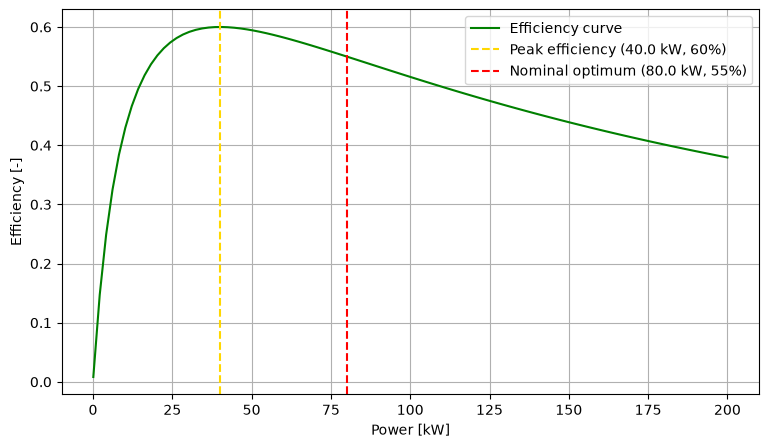

In [5]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 200.0   # kW
p_nom = 80.0    # kW
LHV = 120.0     # kJ/g

p_peak = 40.0   # kW (Enforced peak efficiency point)
eta_peak = 0.60 # Peak efficiency
eta_target_nom = 0.55 # Target efficiency at p_nom

# Fuel consumption at peak and nominal target
f_peak = p_peak / (eta_peak * LHV)
f_nom = p_nom / (eta_target_nom * LHV)

# Analytical derivation enforcing the efficiency peak (zero slope of efficiency at p_peak)
# Efficiency eta(P) = P / ((a2*P^2 + a1*P + a0) * LHV)
# Maximizing efficiency at p_peak implies a0 = a2 * p_peak^2
# Therefore, we solve for a2 and a1 using p_peak and p_nom constraints:
# 1) a2 * p_peak^2 + a1 * p_peak + a0 = f_peak -> 2 * a2 * p_peak^2 + a1 * p_peak = f_peak (since a0 = a2*p_peak^2)
# Let's solve the linear system for [a2, a1]:
# Matrix form: A * X = B
A = np.ar_matrix = [
    [p_peak**2 + p_peak**2, p_peak],
    [p_nom**2, p_nom]
]
# Using the standard vertex-shifted parabolic form for consumption F(P) = a2*(P - p_peak)^2 + f_peak * (p_peak/P) ... 
# Rigorous exact fit via direct least squares / linear constraints:
mat = np.array([
    [p_peak**2, p_peak, 1.0],
    [p_nom**2, p_nom, 1.0],
    [2.0 * p_peak, 1.0, 0.0]  # Derivative condition: dF/dP = 1/LHV * (1/eta_peak) at vertex optimization
])

rhs = np.array([f_peak, f_nom, 1.0 / (eta_peak * LHV)])
a2, a1, a0 = np.linalg.solve(mat, rhs)

print("Coefficients:")
print(f"  a2: {a2:.8e} g/(s·kW²)")
print(f"  a1: {a1:.8e} g/(s·kW)")
print(f"  a0: {a0:.8e} g/s")

eta_at_peak = p_peak / ((a2 * p_peak**2 + a1 * p_peak + a0) * LHV)
eta_at_nom = p_nom / ((a2 * p_nom**2 + a1 * p_nom + a0) * LHV)
print(f"Efficiency at peak ({p_peak} kW): {eta_at_peak:.2%}")
print(f"Efficiency at nominal ({p_nom} kW): {eta_at_nom:.2%}")

# Efficiency curve plotting
p_vec = np.linspace(0.1, p_max, 100)
eta_vec = p_vec / (a2 * p_vec**2 + a1 * p_vec + a0) / LHV

plt.figure(figsize=(9, 5))
plt.plot(p_vec, eta_vec, label="Efficiency curve", color="green")
plt.axvline(p_peak, color="gold", linestyle="--", label=f"Peak efficiency ({p_peak} kW, {eta_at_peak:.0%})")
plt.axvline(p_nom, color="red", linestyle="--", label=f"Nominal optimum ({p_nom} kW, {eta_at_nom:.0%})")
plt.xlabel("Power [kW]")
plt.ylabel("Efficiency [-]")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 800.0   # kW
p_nom = 0.4 * p_max   # kW (optimal operating point for component lifetime)
LHV = 120000.0     # kJ/kg

# --- Physical choices ---
p_peak = 0.2 * p_max   # Forcing the efficiency peak at 40 kW (20% of P_max)
eta_peak = 0.60 # Peak efficiency (60%)
eta_nom = 0.55  # Target efficiency at nominal power (55%)

# --- Parameter calculations ---
# The math now derives alpha using the nominal point instead of the maximum power point
alpha = p_nom / (p_nom - p_peak)**2 * (1.0 / eta_nom - 1.0 / eta_peak)
beta = 1.0 / eta_peak - 2.0 * alpha * p_peak
gamma = alpha * p_peak ** 2

a, b, c = alpha / LHV, beta / LHV, gamma / LHV

# --- Qualitative verifications ---
print("Calculated coefficients:")
print(f"  a (quadratic losses)  : {a:.8e} (Physically coherent: {a > 0})")
print(f"  b (active consumption): {b:.8e} (Physically coherent: {b > 0})")
print(f"  c (standby/idle losses): {c:.8e} (Physically coherent: {c > 0})")

eta_at_nom = p_nom / ((a * p_nom**2 + b * p_nom + c) * LHV)
print(f"Resulting efficiency at the nominal point ({p_nom} kW): {eta_at_nom:.2%}")

eta_at_max = p_max / ((a * p_max**2 + b * p_max + c) * LHV)
print(f"Resulting efficiency at maximum power ({p_max} kW): {eta_at_max:.2%}")

# --- Plotting the efficiency curve ---
p_vec = np.linspace(0.1, p_max, 100)
plt.figure(figsize=(9, 5))
plt.plot(p_vec, p_vec / (a * p_vec**2 + b * p_vec + c) / LHV, label="Physical efficiency curve", color="green")
plt.axvline(p_peak, color="gold", linestyle="--", label=f"Thermodynamic efficiency peak ({p_peak} kW)")
plt.axvline(p_nom, color="red", linestyle="--", label=f"Operational/durability optimum ({p_nom} kW)")
plt.xlabel("Power [kW]")
plt.ylabel("Efficiency [-]")
plt.legend()
plt.grid(True)
plt.show()

print(f"a0: float ={c:.8e}    # [g/s]")
print(f"a1: float ={b:.8e}    # [g/(s*kW)]")
print(f"a2: float ={a:.8e}    # [g/(s*kW^2)]")

Calculated coefficients:
  a (quadratic losses)  : 1.57828283e-08 (Physically coherent: True)
  b (active consumption): 8.83838384e-06 (Physically coherent: True)
  c (standby/idle losses): 4.04040404e-04 (Physically coherent: True)
Resulting efficiency at the nominal point (320.0 kW): 55.00%
Resulting efficiency at maximum power (800.0 kW): 37.93%


a0: float =4.04040404e-04    # [g/s]
a1: float =8.83838384e-06    # [g/(s*kW)]
a2: float =1.57828283e-08    # [g/(s*kW^2)]
